# Supervised AudioMAE fine-tune baseline

**Resume:** флаги `RESUME_FROM_BEST`, `CLEARML_CONTINUE_LAST`, `CLEARML_TASK_ID` — в ячейке инициализации (перед `Task.init`).

Pretrained ViT-B (AudioSet-2M): `checkpoints/audiomae_pretrained.pth` — `python scripts/download_audiomae_pretrained.py` или [Drive](https://drive.google.com/file/d/1ni_DV4dRf7GxM8k-Eirx71WP9Gg89wwu/view?usp=share_link).


In [1]:
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings(
    "ignore",
    message="Importing from timm.models.layers is deprecated*",
    category=FutureWarning,
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ClearML и пути

Пути к данным и чекпоинтам, `.env`, device, **ClearML**


In [2]:
PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
if not (PROJECT_DIR / "audiomae_bat.py").is_file():
    PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from audiomae_bat import (
    build_audio_mae_base,
    cls_embedding,
    load_audio_mae_checkpoint,
    waveform_to_audiomae_input,
)

DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
AUDIOMAE_PRETRAINED = CHECKPOINT_DIR / "audiomae_pretrained.pth"
BEST_CKPT = CHECKPOINT_DIR / "audiomae_bat_finetune_best.pt"
TRAIN_LOG_TXT = CHECKPOINT_DIR / "audiomae_bat_train_log.txt"

import logging
from dotenv import load_dotenv

load_dotenv(PROJECT_DIR / ".env", override=False)

CLEARML_QUIET = os.environ.get("CLEARML_QUIET", "1").strip().lower() in ("1", "true", "yes")
CLEARML_UPLOAD_EACH_BEST = os.environ.get("CLEARML_UPLOAD_EACH_BEST", "0").strip().lower() in (
    "1", "true", "yes",
)


def setup_clearml_console(quiet: bool = True) -> None:
    if not quiet:
        return
    for name in ("clearml", "clearml.storage", "clearml.model", "clearml.Task"):
        logging.getLogger(name).setLevel(logging.WARNING)
    try:
        from clearml.storage.callbacks import ProgressReport

        def _no_tqdm(self):
            self._tqdm_init = True
            return None

        ProgressReport._get_tqdm = _no_tqdm
    except Exception:
        pass


setup_clearml_console(CLEARML_QUIET)

from clearml import OutputModel, Task

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# --- ClearML ---
RESUME_FROM_BEST = True
CLEARML_CONTINUE_LAST = True   # дописать метрики в ту же ClearML Task
CLEARML_TASK_ID = None         # явный ID задачи
CLEARML_PROJECT = "my project"
CLEARML_TASK_NAME = "audiomae_bat_baseline_2sec"

clearml_output_uri = os.environ.get("CLEARML_OUTPUT_URI", True)
if isinstance(clearml_output_uri, str) and clearml_output_uri.lower() in ("false", "0", "no", "none"):
    clearml_output_uri = False

_task_init_kw = dict(
    project_name=CLEARML_PROJECT,
    task_name=CLEARML_TASK_NAME,
    output_uri=clearml_output_uri,
    auto_resource_monitoring=False,
)
if CLEARML_TASK_ID:
    _task_init_kw["continue_last_task"] = CLEARML_TASK_ID
    _task_init_kw["reuse_last_task_id"] = CLEARML_TASK_ID
elif CLEARML_CONTINUE_LAST and RESUME_FROM_BEST:
    _task_init_kw["continue_last_task"] = 0
    _task_init_kw["reuse_last_task_id"] = True
else:
    _task_init_kw["reuse_last_task_id"] = False

clearml_task = Task.init(**_task_init_kw)
output_dest = clearml_task.get_output_destination() or ""
output_model = OutputModel(
    task=clearml_task,
    name="audiomae_bat_baseline",
    framework="pytorch",
)
if output_dest:
    output_model.set_upload_destination(output_dest)

if not CLEARML_QUIET:
    print("ClearML:", clearml_task.get_output_log_web_page())
print(
    "device:", device,
    "| quiet:", CLEARML_QUIET,
    "| upload each best:", CLEARML_UPLOAD_EACH_BEST,
    "| clearml continue:", (CLEARML_CONTINUE_LAST and RESUME_FROM_BEST) or bool(CLEARML_TASK_ID),
    "| clearml task:", clearml_task.id,
)


ClearML Task: overwriting (reusing) task id=3e114223dd65406c90f160433317ba45
ClearML results page: https://app.clear.ml/projects/6c3eac4aaa974ff39b83424d3f26990c/experiments/3e114223dd65406c90f160433317ba45/output/log
device: mps | quiet: True | upload each best: False | clearml continue: True | clearml task: 3e114223dd65406c90f160433317ba45


# Аудио и crop

**192 kHz**, клип **2 с**. На train — energy-biased или random crop, на val — center crop. Затем waveform - Kaldi fbank 1024×128 для AudioMAE (ресемпл в 16 kHz внутри `waveform_to_audiomae_input`).


In [3]:
TARGET_SR = 192_000
CLIP_SEC = 2.0

ENERGY_CROP_PROB = 0.7
ENERGY_CROP_CANDIDATES = 8
WAV_GAIN_JITTER_DB = 6.0


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def random_crop_or_pad(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if len(y) >= target_len:
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def energy_biased_crop(
    y: np.ndarray, target_len: int, rng: np.random.Generator, n_candidates: int
) -> np.ndarray:
    if len(y) < target_len:
        return center_crop_or_pad(y, target_len)
    best_i0, best_e = 0, -1.0
    for _ in range(n_candidates):
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        seg = y[i0 : i0 + target_len]
        e = float(np.mean(seg * seg))
        if e > best_e:
            best_e, best_i0 = e, i0
    return y[best_i0 : best_i0 + target_len]


def pick_train_crop(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if rng.random() < ENERGY_CROP_PROB:
        return energy_biased_crop(y, target_len, rng, ENERGY_CROP_CANDIDATES)
    return random_crop_or_pad(y, target_len, rng)


def maybe_gain_jitter(y: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    if WAV_GAIN_JITTER_DB <= 0:
        return y
    gain = 10.0 ** (float(rng.uniform(-WAV_GAIN_JITTER_DB, WAV_GAIN_JITTER_DB)) / 20.0)
    return (y * gain).astype(np.float32)


# Датасет (метаданные)

Загрузка CSV, пути к WAV, stratified split 85/15.


In [4]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]), axis=1
)
df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Классов: {n_classes}")

vc_train = train_df["species"].value_counts().sort_values()
print(
    f"Классы train: min={vc_train.min()} max={vc_train.max()} "
    f"ratio={vc_train.max() / max(vc_train.min(), 1):.2f}"
)
display(vc_train.head(8))


Train: 4348  Val: 768  Классов: 26
Классы train: min=133 max=170 ratio=1.28


species
LABL    133
COTO    142
NYMA    163
LASE    170
MYYU    170
MYSO    170
MYVO    170
PAHE    170
Name: count, dtype: int64

# Dataset

`BatWavMelAudioMAEDataset`: WAV - crop - `waveform_to_audiomae_input` - `[1, 1024, 128]`.


In [5]:
class BatWavMelAudioMAEDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.training = training
        self.rng = np.random.default_rng(RANDOM_SEED)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        if self.training:
            y = pick_train_crop(y, tgt, self.rng)
            y = maybe_gain_jitter(y, self.rng)
        else:
            y = center_crop_or_pad(y, tgt)
        wav = torch.from_numpy(np.ascontiguousarray(y, dtype=np.float32))
        mel = waveform_to_audiomae_input(wav, float(TARGET_SR))
        return mel.squeeze(0).contiguous().float(), int(row["label"])


# DataLoader

`WeightedRandomSampler` на train.


In [6]:
train_ds = BatWavMelAudioMAEDataset(train_df, training=True)
val_ds = BatWavMelAudioMAEDataset(val_df, training=False)

label_counts = train_df["label"].value_counts().sort_index()
inv_count = {lbl: 1.0 / cnt for lbl, cnt in label_counts.items()}
sample_weights = train_df["label"].map(inv_count).values
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.as_tensor(
        np.asarray(sample_weights, dtype=np.float64).copy(), dtype=torch.double
    ),
    num_samples=len(train_df),
    replacement=True,
)

BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

xb, yb = next(iter(train_loader))
print("mel batch:", xb.shape, "labels:", yb.shape)


mel batch: torch.Size([8, 1, 1024, 128]) labels: torch.Size([8])


# AudioMAE

Загрузка `audiomae_pretrained.pth`, классификатор с отдельным LR для encoder и head.


In [7]:
class BatSpeciesClassifier(nn.Module):
    """CLS-представление AudioMAE encoder - голова классификации."""

    def __init__(self, encoder: nn.Module, num_classes: int):
        super().__init__()
        self.encoder = encoder
        d = encoder.embed_dim
        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Dropout(0.2),
            nn.Linear(d, num_classes),
        )

    def forward(self, x):
        z = cls_embedding(self.encoder, x)
        return self.head(z)


_pretrained_ok = False
encoder = build_audio_mae_base()
if AUDIOMAE_PRETRAINED.is_file():
    load_audio_mae_checkpoint(encoder, AUDIOMAE_PRETRAINED, strict=False)
    _pretrained_ok = True
    print("pretrained:", AUDIOMAE_PRETRAINED)
else:
    print("WARNING: random init AudioMAE (нет", AUDIOMAE_PRETRAINED, ")")

encoder = encoder.to(device)
classifier = BatSpeciesClassifier(encoder, num_classes=n_classes).to(device)

n_params = sum(p.numel() for p in classifier.parameters())
print(f"AudioMAE classifier params: {n_params:,}")
with torch.no_grad():
    print("logits:", classifier(xb.to(device)).shape)


pretrained: /Users/katterns/ITMO/Practice/checkpoints/audiomae_pretrained.pth
AudioMAE classifier params: 111,677,978
logits: torch.Size([8, 26])


# Гиперпараметры

AdamW (разный LR encoder/head), `ReduceLROnPlateau`, label smoothing.


In [8]:
LR = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
MAX_EPOCHS = 40
PATIENCE = 10
LR_PLATEAU_PATIENCE = 5
LR_FACTOR = 0.5
LR_MIN = 1e-7
MAX_GRAD_NORM = 1.0

RESUME_LOWER_LR = True
FINETUNE_BACKBONE_LR = 5e-6
FINETUNE_HEAD_LR = 1e-4

BACKBONE_LR = 1e-5 if _pretrained_ok else 5e-4
HEAD_LR = 3e-4

clearml_task.connect({
    "model": "audiomae_vit_base",
    "clip_sec": CLIP_SEC,
    "energy_crop_prob": ENERGY_CROP_PROB,
    "batch_size": BATCH_SIZE,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "label_smoothing": LABEL_SMOOTHING,
    "pretrained_loaded": _pretrained_ok,
    "device": str(device),
    "resume_from_best": RESUME_FROM_BEST,
    "clearml_continue_last": CLEARML_CONTINUE_LAST,
})

loss_function = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(
    [
        {"params": classifier.encoder.parameters(), "lr": BACKBONE_LR},
        {"params": classifier.head.parameters(), "lr": HEAD_LR},
    ],
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PLATEAU_PATIENCE,
    min_lr=LR_MIN,
)


# Обучение

`evaluate`, `train_model`, early stopping. При `RESUME_FROM_BEST=True` и наличии `audiomae_bat_finetune_best.pt` — продолжение с **epoch+1** и лучшего macro-F1 из чекпоинта.


In [9]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    loss_epoch = 0.0
    num_samples = 0
    preds_list, targets_list = [], []

    for batch_x, target in val_loader:
        batch_x = batch_x.to(device)
        target = target.to(device)
        logits = model(batch_x)
        loss = loss_function(logits, target)
        num = logits.shape[0]
        loss_epoch += loss.item() * num
        num_samples += num
        preds_list.extend(logits.argmax(dim=-1).cpu().tolist())
        targets_list.extend(target.cpu().tolist())

    y_true = np.array(targets_list)
    y_pred = np.array(preds_list)
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_prec": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }
    return loss_epoch / max(num_samples, 1), metrics, y_true, y_pred


def _upload_checkpoint_to_clearml(epoch: int) -> str | None:
    if not output_dest:
        return None
    return output_model.update_weights(
        weights_filename=str(BEST_CKPT),
        upload_uri=output_dest or None,
        auto_delete_file=False,
        iteration=epoch,
    )


def _save_best_checkpoint(epoch, macro_f1, metrics):
    torch.save(
        {
            "classifier_state": classifier.state_dict(),
            "model_name": "audiomae_bat",
            "label2id": label2id,
            "id2label": {str(k): v for k, v in id2label.items()},
            "config": {
                "target_sr": TARGET_SR,
                "clip_sec": CLIP_SEC,
                "mel_shape": [1024, 128],
                "pretrained_loaded": _pretrained_ok,
                "backbone_lr": BACKBONE_LR,
                "head_lr": HEAD_LR,
                "label_smoothing": LABEL_SMOOTHING,
                "energy_crop_prob": ENERGY_CROP_PROB,
            },
            "val_macro_f1": macro_f1,
            "val_weighted_f1": metrics["weighted_f1"],
            "val_balanced_acc": metrics["bal_acc"],
            "epoch": epoch,
        },
        BEST_CKPT,
    )
    model_uri = None
    if CLEARML_UPLOAD_EACH_BEST:
        model_uri = _upload_checkpoint_to_clearml(epoch)
    line = f"epoch={epoch} macro_f1={macro_f1:.4f} w_f1={metrics['weighted_f1']:.4f}\n"
    TRAIN_LOG_TXT.write_text(
        (TRAIN_LOG_TXT.read_text(encoding="utf-8") if TRAIN_LOG_TXT.exists() else "")
        + line,
        encoding="utf-8",
    )
    if CLEARML_QUIET:
        tqdm.write(f"saved {BEST_CKPT.name}  macro_f1={macro_f1:.4f}")
    else:
        msg = f"saved {BEST_CKPT}"
        if model_uri:
            msg += f"  ClearML: {model_uri}"
        tqdm.write(msg)


def _load_resume_checkpoint(model, ckpt_path: Path):
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Resume: нет файла {ckpt_path}")

    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)

    model.load_state_dict(ckpt["classifier_state"], strict=True)

    ckpt_labels = ckpt.get("label2id") or {}
    if set(ckpt_labels.keys()) != set(label2id.keys()):
        tqdm.write("WARNING: label2id в чекпоинте отличается от текущего split")

    last_epoch = int(ckpt.get("epoch", 0))
    best_macro_f1 = float(ckpt.get("val_macro_f1", -1.0))
    start_epoch = last_epoch + 1
    return start_epoch, best_macro_f1, last_epoch


def _apply_finetune_lr():
    for pg in optimizer.param_groups:
        is_backbone = pg is optimizer.param_groups[0]
        pg["lr"] = FINETUNE_BACKBONE_LR if is_backbone else FINETUNE_HEAD_LR
    tqdm.write(
        f"Finetune LR: backbone={FINETUNE_BACKBONE_LR:.2e} head={FINETUNE_HEAD_LR:.2e}"
    )


def train_model(
    model,
    num_epochs=40,
    max_grad_norm=1.0,
    resume_from_best: bool = False,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "val_acc": [],
    }
    best_macro_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0
    start_epoch = 1

    if resume_from_best:
        start_epoch, best_macro_f1, best_epoch = _load_resume_checkpoint(model, BEST_CKPT)
        if RESUME_LOWER_LR:
            _apply_finetune_lr()
        tqdm.write(
            f"Resume: {BEST_CKPT.name}  last_epoch={best_epoch}  "
            f"best_macro_f1={best_macro_f1:.4f}, epochs {start_epoch}..{num_epochs}"
        )
        if start_epoch > num_epochs:
            raise ValueError(
                f"Resume: start_epoch={start_epoch} > MAX_EPOCHS={num_epochs}. "
            )

    logger = clearml_task.get_logger()

    epoch_bar = tqdm(
        range(start_epoch, num_epochs + 1),
        desc="epochs",
        unit="epoch",
        initial=start_epoch - 1,
        total=num_epochs,
    )
    for epoch in epoch_bar:
        model.train()
        epoch_train_loss = 0.0
        epoch_train_n = 0

        batch_bar = tqdm(
            train_loader,
            desc=f"train e{epoch}",
            leave=False,
            unit="batch",
            position=1,
        )
        for batch_x, target in batch_bar:
            batch_x = batch_x.to(device)
            target = target.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = loss_function(logits, target)
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            batch_n = batch_x.size(0)
            epoch_train_loss += loss.item() * batch_n
            epoch_train_n += batch_n
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        tr_loss = epoch_train_loss / max(epoch_train_n, 1)
        val_loss, metrics, y_true, y_pred = evaluate(model)
        lr_now = optimizer.param_groups[0]["lr"]
        macro_f1 = metrics["macro_f1"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(macro_f1)
        history["val_weighted_f1"].append(metrics["weighted_f1"])
        history["val_acc"].append(metrics["acc"])

        for name, val in metrics.items():
            logger.report_scalar("metrics", name, val, iteration=epoch)
        logger.report_scalar("loss", "train", tr_loss, iteration=epoch)
        logger.report_scalar("loss", "val", val_loss, iteration=epoch)
        logger.report_scalar("lr", "lr", lr_now, iteration=epoch)

        pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
        epoch_bar.set_postfix(macro_f1=f"{macro_f1:.4f}", val_loss=f"{val_loss:.4f}")
        tqdm.write(
            f"Epoch {epoch:02d}  lr={lr_now:.2e}  train={tr_loss:.4f}  val={val_loss:.4f}  "
            f"acc={metrics['acc']:.4f}  macro_f1={macro_f1:.4f}  "
            f"w_f1={metrics['weighted_f1']:.4f}  w_prec={metrics['weighted_prec']:.4f}  "
            f"top3={pred_top3}"
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch
            epochs_no_improve = 0
            _save_best_checkpoint(epoch, macro_f1, metrics)
        else:
            epochs_no_improve += 1

        scheduler.step(macro_f1)

        if epochs_no_improve >= PATIENCE:
            tqdm.write("Early stopping.")
            break

    epoch_bar.close()
    if best_macro_f1 > 0 and output_dest and not CLEARML_UPLOAD_EACH_BEST:
        uri = _upload_checkpoint_to_clearml(best_epoch)
        if not CLEARML_QUIET and uri:
            tqdm.write(f"ClearML upload (final best, ep {best_epoch}): {uri}")
    tqdm.write(f"best macro_f1 (val): {best_macro_f1:.4f}")
    return model, history


# Запуск обучения

In [10]:
model, history = train_model(
    classifier,
    num_epochs=MAX_EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    resume_from_best=RESUME_FROM_BEST,
)


Finetune LR: backbone=5.00e-06 head=1.00e-04
Resume: audiomae_bat_finetune_best.pt  last_epoch=26  best_macro_f1=0.3355, epochs 27..40


epochs:  65%|######5   | 26/40 [00:00<?, ?epoch/s]

train e27:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 27  lr=5.00e-06  train=1.7002  val=2.5126  acc=0.3346  macro_f1=0.3114  w_f1=0.3120  w_prec=0.3257  top3={'MYLE': 81, 'NYMA': 58, 'PAHE': 54}


train e28:   0%|          | 0/544 [00:00<?, ?batch/s]

...

Epoch 36  lr=2.50e-06  train=1.5687  val=2.6097  acc=0.3503  macro_f1=0.3274  w_f1=0.3280  w_prec=0.3214  top3={'MYSE': 53, 'NYMA': 47, 'MYCI': 46}


train e37:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 37  lr=2.50e-06  train=1.5651  val=2.6170  acc=0.3503  macro_f1=0.3356  w_f1=0.3361  w_prec=0.3404  top3={'MYLE': 59, 'MYVO': 56, 'NYMA': 54}


train e38:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 38  lr=2.50e-06  train=1.5385  val=2.6068  acc=0.3490  macro_f1=0.3331  w_f1=0.3341  w_prec=0.3352  top3={'LACI': 57, 'MYLE': 52, 'PESU': 44}
Early stopping.
best macro_f1 (val): 0.3403


# Оценка на validation

Лучший чекпоинт, classification report и confusion matrix.


2026-05-27 11:38:43,433 - clearml.model - WARNING - Connecting multiple input models with the same name: `audiomae_bat_finetune_best`. This might result in the wrong model being used when executing remotely
epoch: 28
macro F1: 0.3402987663914727
weighted F1: 0.34075630200392254
weighted precision: 0.3416164243546884
balanced acc: 0.36013483642793986
accuracy: 0.3606770833333333

              precision    recall  f1-score   support

        ANPA       0.13      0.07      0.09        30
        COTO       0.26      0.20      0.23        25
        EPFU       0.35      0.20      0.26        30
        EUMA       0.90      0.87      0.88        30
        LABL       0.36      0.38      0.37        24
        LABO       0.56      0.47      0.51        30
        LACI       0.11      0.03      0.05        30
        LAIN       0.68      0.70      0.69        30
        LANO       0.06      0.07      0.06        30
        LASE       0.81      0.83      0.82        30
        MYCA       0.04

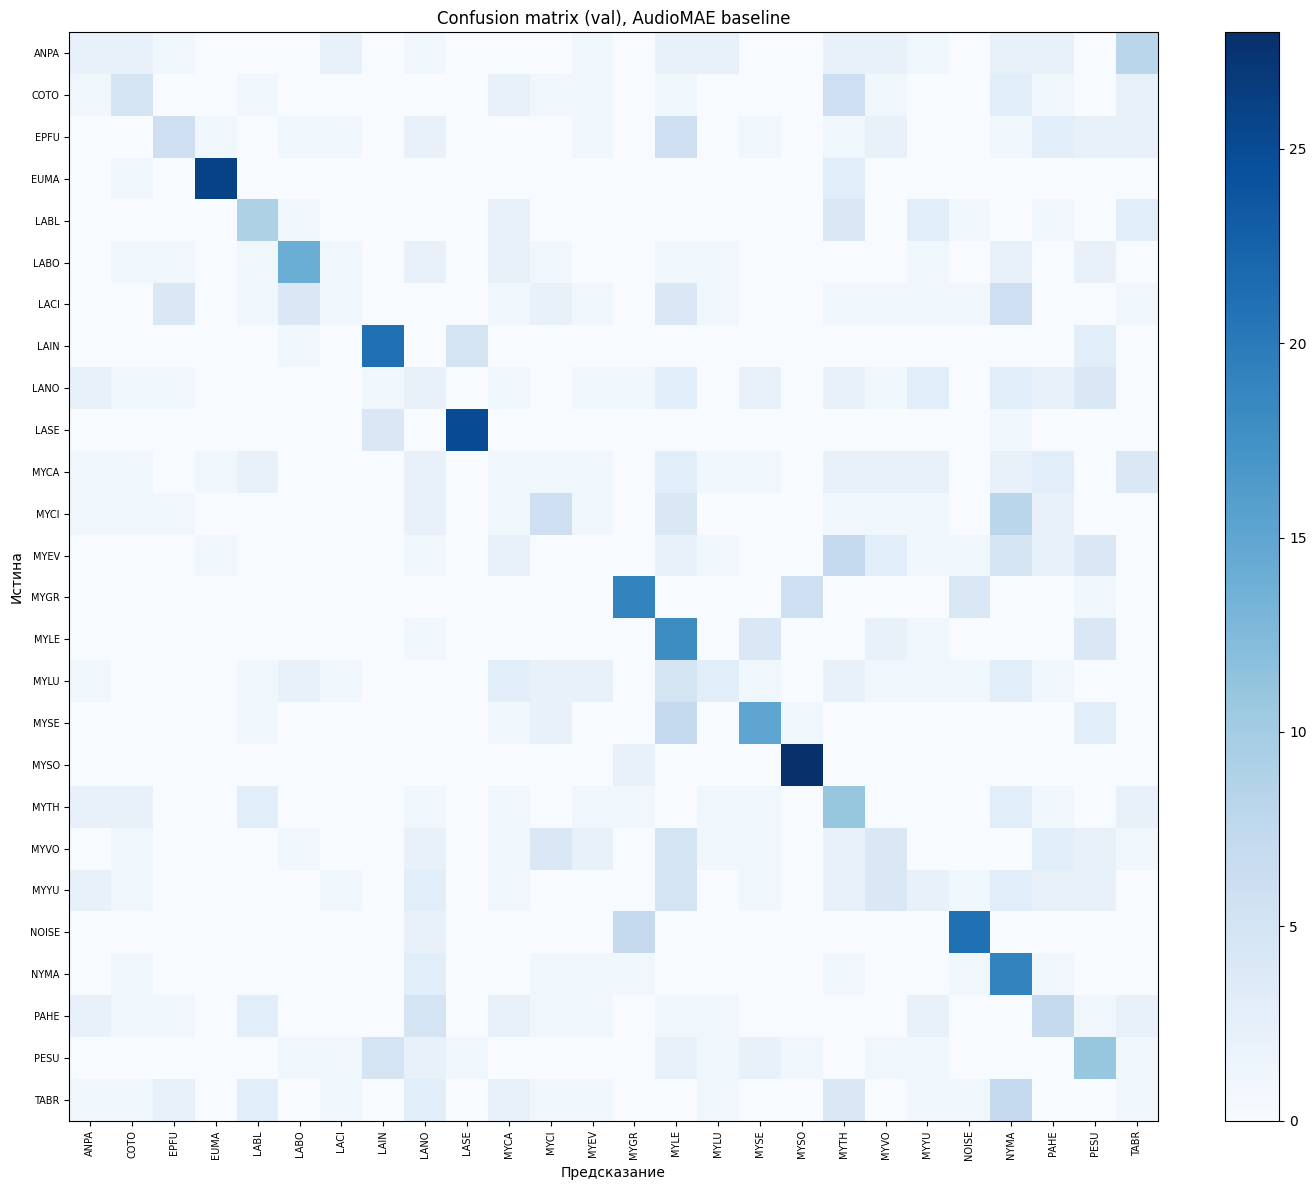

In [11]:
try:
    ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
except TypeError:
    ckpt = torch.load(BEST_CKPT, map_location=device)

classifier.load_state_dict(ckpt["classifier_state"])

val_loss, metrics, y_true, y_pred = evaluate(classifier)
print("epoch:", ckpt.get("epoch"))
print("macro F1:", metrics["macro_f1"])
print("weighted F1:", metrics["weighted_f1"])
print("weighted precision:", metrics["weighted_prec"])
print("balanced acc:", metrics["bal_acc"])
print("accuracy:", metrics["acc"])
print()
print(classification_report(y_true, y_pred, target_names=species_sorted, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(species_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(species_sorted, fontsize=7)
ax.set_ylabel("Истина")
ax.set_xlabel("Предсказание")
ax.set_title("Confusion matrix (val), AudioMAE baseline")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
